.<center> 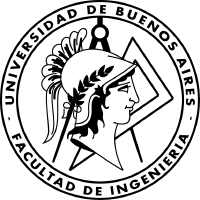



**Universidad de Buenos Aires**

**Facultad de Ingeniería**

**2do Cuatrimestre de 2025**

**Taller de Procesamiento de Señales**

---

**TP SVM**

**Alumno:** Lo Coco, Manuel - mlococo@fi.uba.ar - 103938 </center>

---


In [2]:
import pickle
import requests

url = "https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/main/data/ejs_svm.pkl"
response = requests.get(url)

# Cargar desde el contenido descargado
data = pickle.loads(response.content)

dataset2 = data['2do Dataset']
X = dataset2['X'].reshape(-1, 1)
y = dataset2['y'].reshape(-1, 1)


### (a)

Se implementa una clasificación SVM con kernel gaussiano ($\gamma=50$) usando la función SVC y con $C=1$

In [11]:
from sklearn.svm import SVC
import numpy as np # Import numpy to use ravel()

X = dataset2['X']
y = dataset2['y']

clf = SVC(C=1,kernel='rbf', gamma = 50)
clf.fit(X, y.ravel()) # Use ravel() to convert y to a 1D array

SVC(C=1, gamma=50)

### (b)

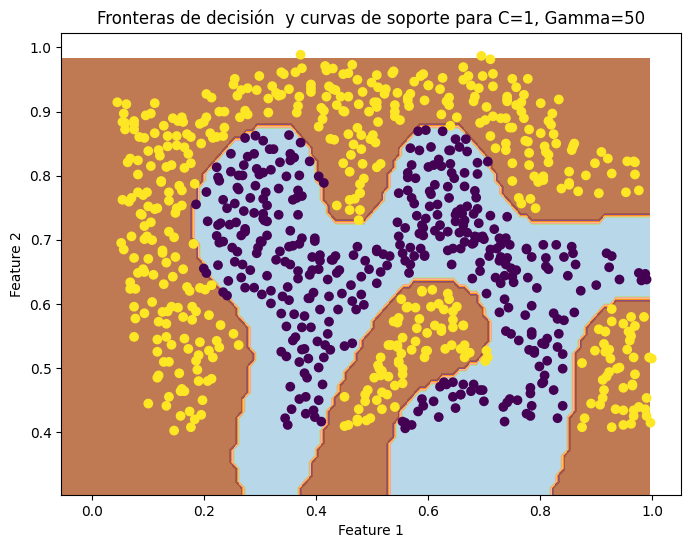

In [12]:
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y, val_c, gamma):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max()
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max()
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),np.arange(y_min, y_max, 0.01))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)

    plt.scatter(X[:, 0], X[:, 1], c=y.ravel())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(f'Fronteras de decisión  y curvas de soporte para C={val_c}, Gamma={gamma}')
    plt.show()


plot_decision_boundary(clf, X, y, 1, 50)

### (c)

Al mantener constante el valor de $\gamma=50$ y variar el parámetro $C$, se observa lo siguiente:


* Para valores pequeños de $C$: el modelo tolera errores para mantener un margen amplio, priorizando la simplicidad de la frontera. Esto provoca subajuste, ya que no logra clasificar correctamente los datos más difíciles.

* Para valores grandes de $C$: el modelo penaliza fuertemente los errores, reduciendo el margen y adaptándose más al conjunto de entrenamiento. Esto genera sobreajuste, con una frontera más compleja y menor capacidad de generalización.

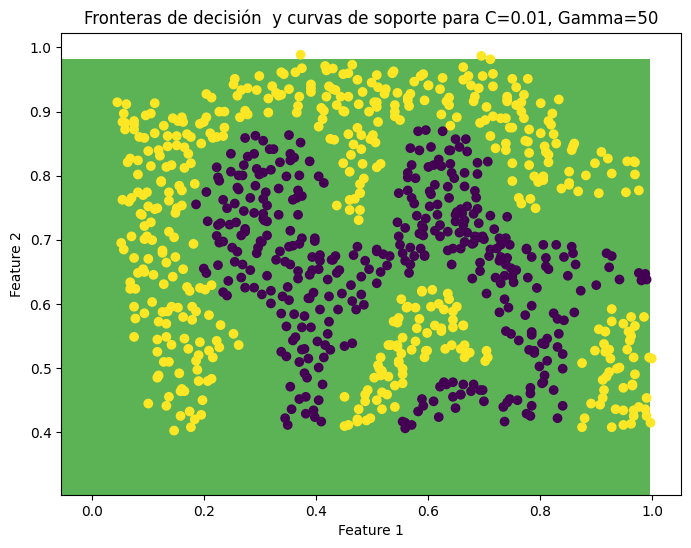

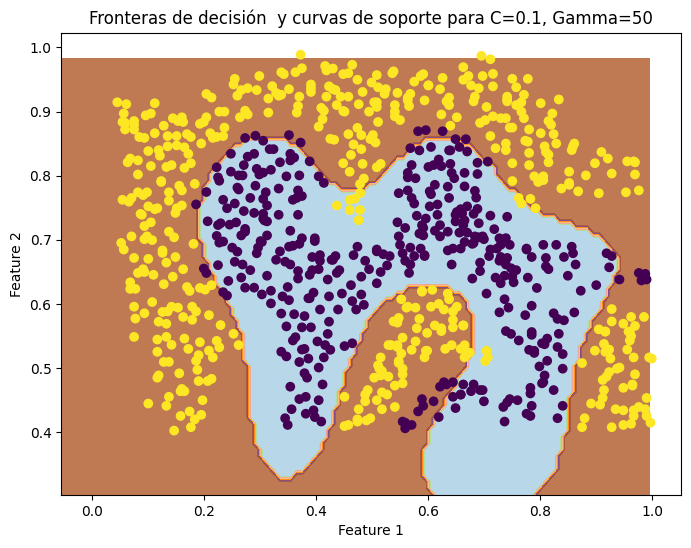

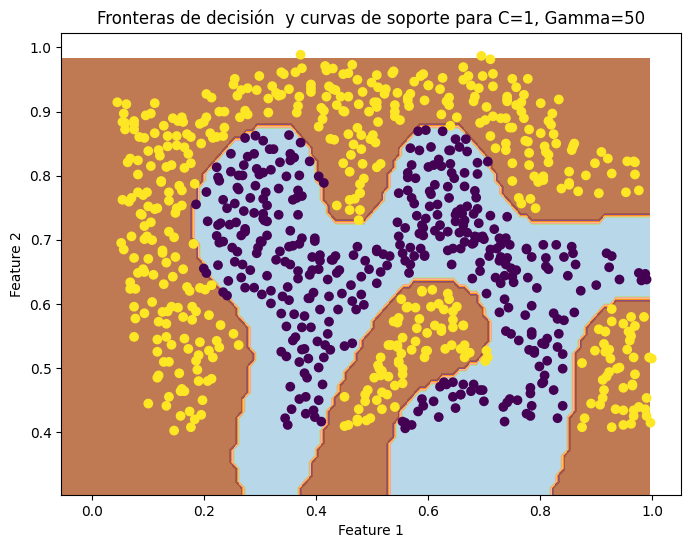

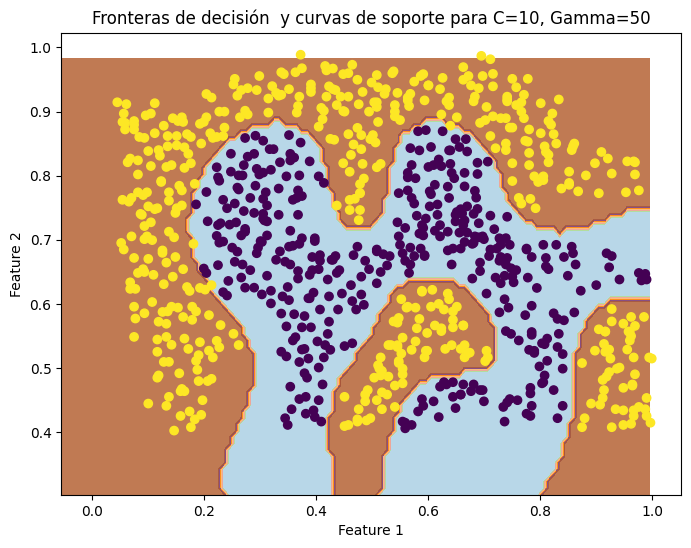

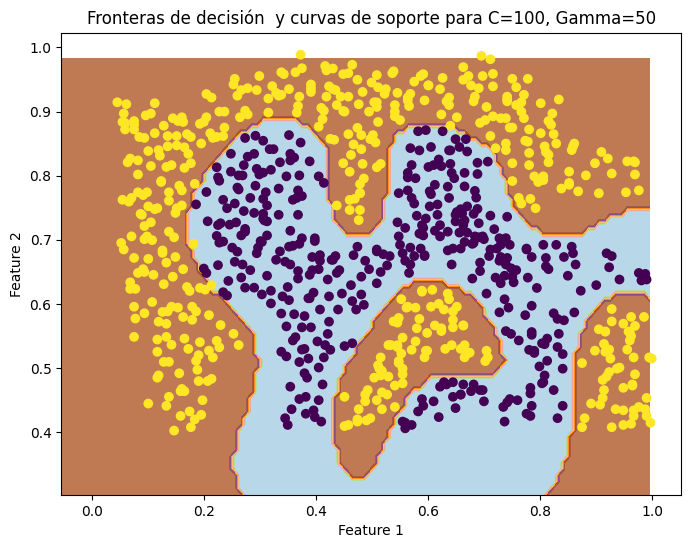

In [6]:
c_values = [0.01, 0.1, 1, 10, 100]
gamma = 50

for val_c in c_values:
  a_c = SVC(C=val_c, gamma = 50)
  a_c.fit(X, y.ravel())
  plot_decision_boundary(a_c, X, y, val_c, gamma)

### (d)

Al mantener constante el valor de $C=1$ y variar el parámetro $\gamma$, se obtienen las siguientes observaciones:

* Para valores pequeños de $\gamma$: la frontera de decisión es suave y general, lo que produce subajuste, ya que el modelo no logra separar correctamente las clases más complejas.

* Para valores grandes de $\gamma$:la frontera se vuelve muy ajustada a los datos de entrenamiento, adaptándose incluso al ruido. Esto genera sobreajuste, con buena clasificación en entrenamiento pero poca capacidad de generalización.

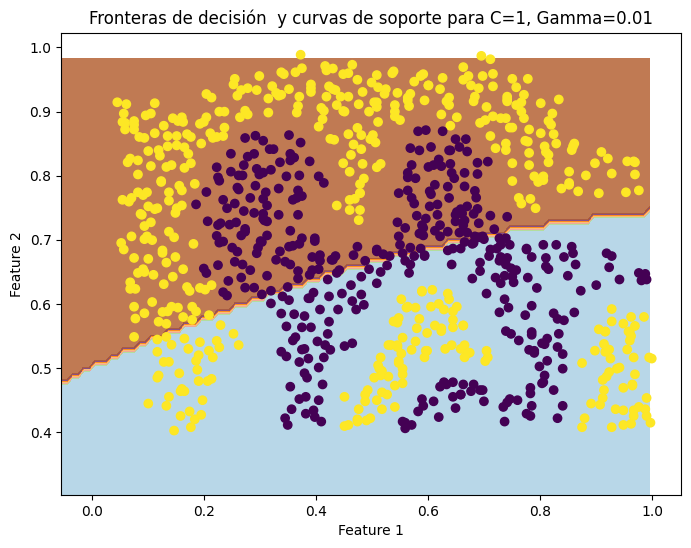

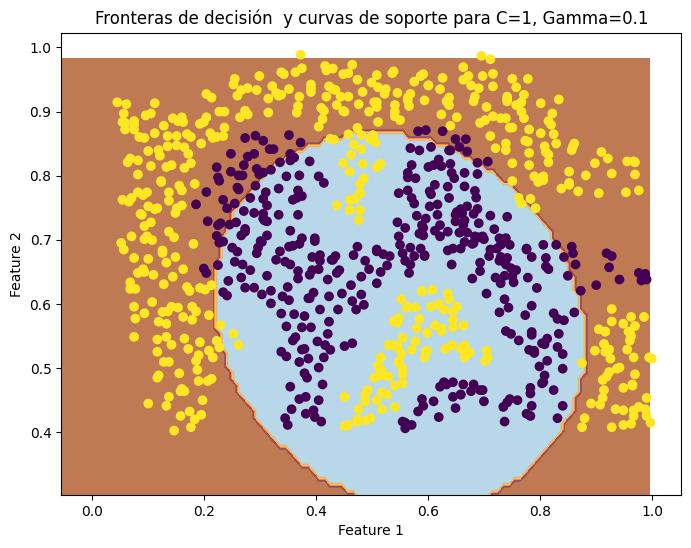

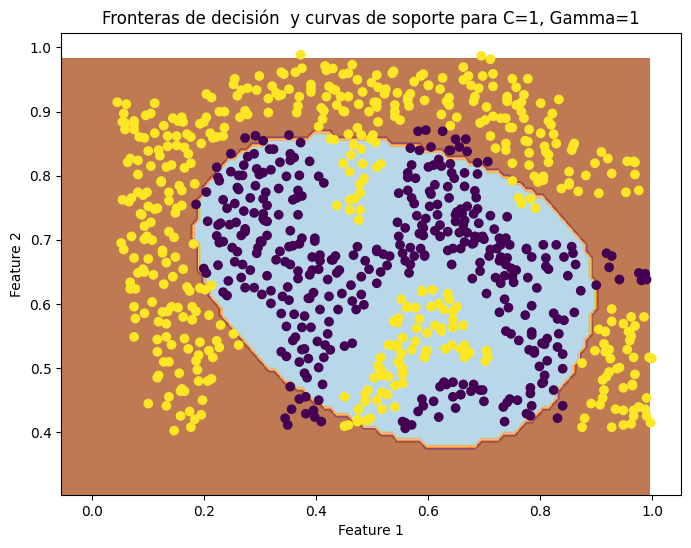

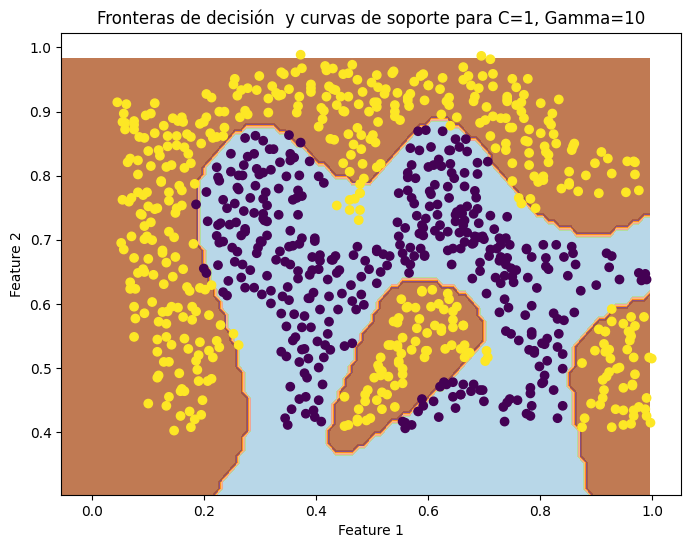

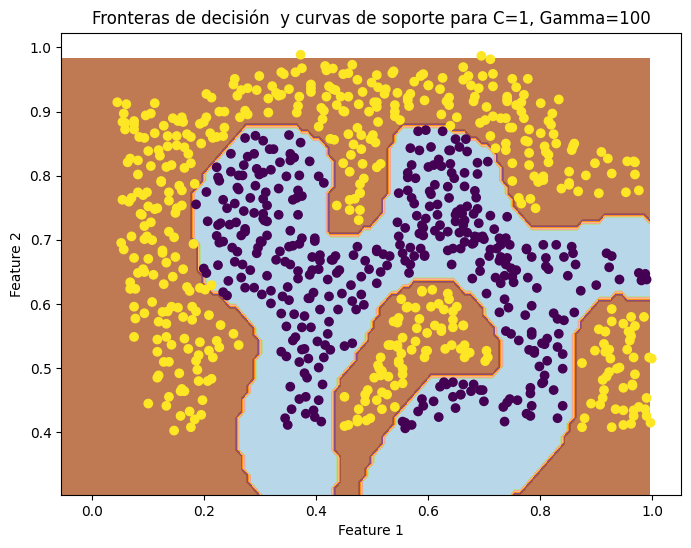

In [7]:
c = 1
gamma_values = [0.01, 0.1, 1, 10, 100]
for val_gamma in c_values:
  a_d = SVC(C=val_c, gamma = val_gamma)
  a_d.fit(X, y.ravel())
  plot_decision_boundary(a_d, X, y, c, val_gamma)